## Example 2f:
Training one model to handle a dynamic number and arrangement of z-planes.

Previous models either hard-coded the z-stack geometry into the learned weights, or assumed exactly one frame at an unknown z-position. Both cases are consequences of the image encoder being a CNN where z-planes act as input channels. Here, we swap that out for an attention-based encoder, which uses a CNN to encode each frame the same way, then pools across the frames using a multiattention head. This architecture should be able to handle any number of z-planes, determined anew at each call time, and should also be permutation equivariant (producing the same results regardless of the order the frames are given in). The input images are no longer strictly z-stacks, but rather, can be thought of as bags of image frames sharing an object and an optical system.

The cross-z attention pooling also lets us query how much attention the model is paying to each z-plane. This dovetails nicely with the information content measurements that we discuss in more detail in `examples/information_theory/`. At the end of this notebook, we'll jump ahead briefly to plot the information vs. z on top of the attention weights to see if they match up.

In [1]:
import logging
from pathlib import Path
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot
from matplotlib.lines import Line2D

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_mixture_config,
    get_default_velocity_config,
)
from cynosure.information.fisher_information import (
    augmented_prior_covariance,
    calculate_augmented_fisher_matrix,
    calculate_mutual_information,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.utilities.visualization import plot_stack
from cynosure.zstack_decoding import ZstackSolver_Covariance
from cynosure.zstack_decoding.geometry_modes import UniformSpanGeometry
from cynosure.zstack_decoding.posterior_heads import get_default_set_encoder_spec

#### Simulation setup

In [4]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config(learning_rate=1.0e-4)
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
mixture_cfg = get_default_mixture_config()

encoder_spec = get_default_set_encoder_spec(
    spatial_hidden_channels=(32, 64),
    image_embedding_dims=128,
    z_embedding_dims=128,
    num_attention_layers=2,
    num_attention_heads=2,
    attention_feedforward_dims=256,
)

geometry = UniformSpanGeometry(
    min_planes=3,
    max_planes=11,
    min_half_span=0.8,
    max_half_span=2.0,
)

In [5]:
rng_seed = 123
z_jitter = 1.0  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Train a model with stochastically-drawn stack geometries

In [6]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_Covariance(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=geometry,
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    encoder_spec=encoder_spec,
)
solver = solver.to(device)

Seed set to 123


In [7]:
checkpoint_path = Path("./pretrained_models/example_2f/checkpoints/final.ckpt")

if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=15,
        accelerator=device,
        log_every_n_steps=50,
        callbacks=[NoValidationBar()],
    )
    trainer.fit(solver)
    solver = solver.eval()

#### Check the results

Each `create_examples` call draws a new stack geometry, with a random number and choice of z-positions. To see the variation, draw a few different size-1 batches separately, and plot the synthesized vs. decoded z-stacks from each.

In [8]:
def generate_reconstruct_plot(
        solver: ZstackSolver_Covariance,
        seed: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Helper function that draws a batch of 1 example with a given RNG seed, makes predictions,
    and plots the resulting z-stacks. Also returns the synthesized and predicted tensors.
    """
    _ = pl.seed_everything(seed, workers=True)
    batch_size = 1
    solver = solver.eval()
    with torch.inference_mode():
        images, z, phase_coefs, amp_coefs = solver.simulator.create_examples(batch_size)
        pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images, z)
        pred_images = solver.simulator.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs, z)

    fig1 = plot_stack(images.squeeze(0).numpy(force=True), panel_size=2)
    fig1.suptitle("synthesized", size=14)
    fig1.tight_layout()

    fig2 = plot_stack(pred_images.squeeze(0).numpy(force=True), panel_size=2)
    fig2.suptitle("decoded and reconstructed", size=14)
    fig2.tight_layout()

    return (
        z,
        images,
        phase_coefs,
        amp_coefs,
        pred_images,
        pred_phase_coefs,
        pred_amp_coefs,
    )

Seed set to 124


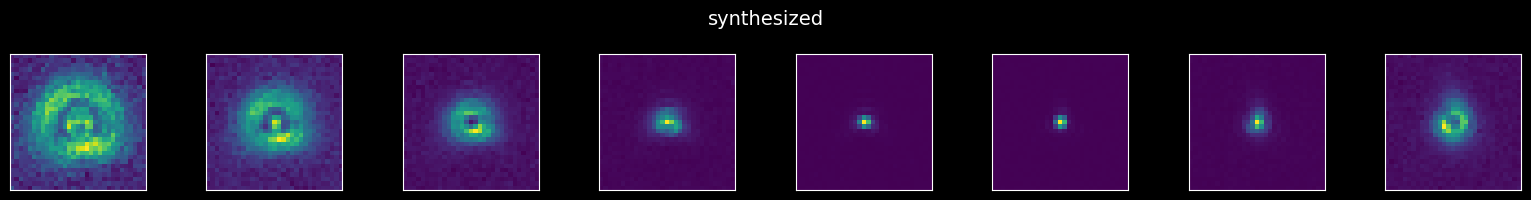

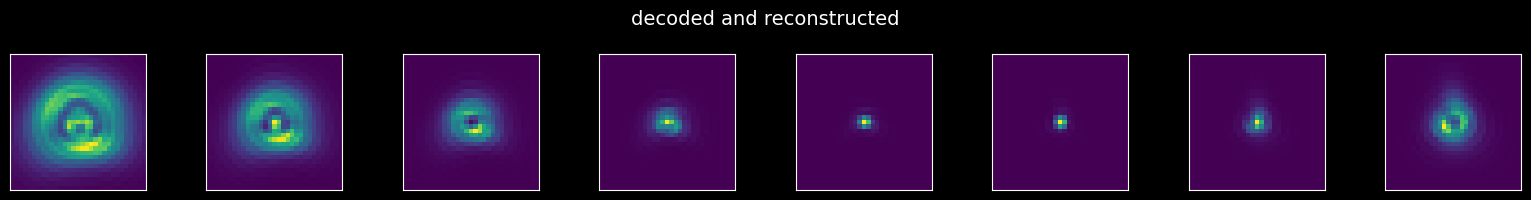

In [9]:
_ = generate_reconstruct_plot(solver, rng_seed+1)

Seed set to 125


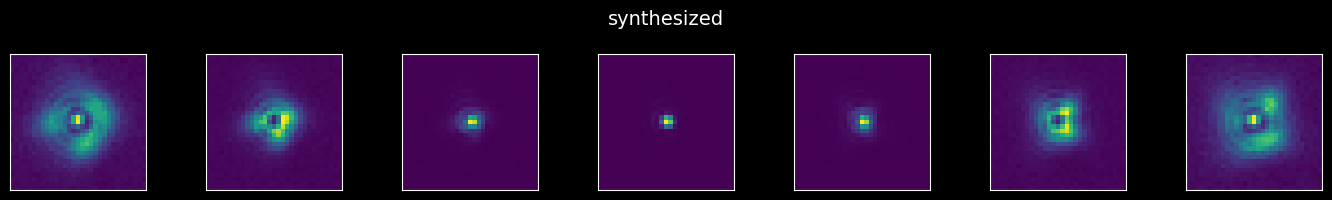

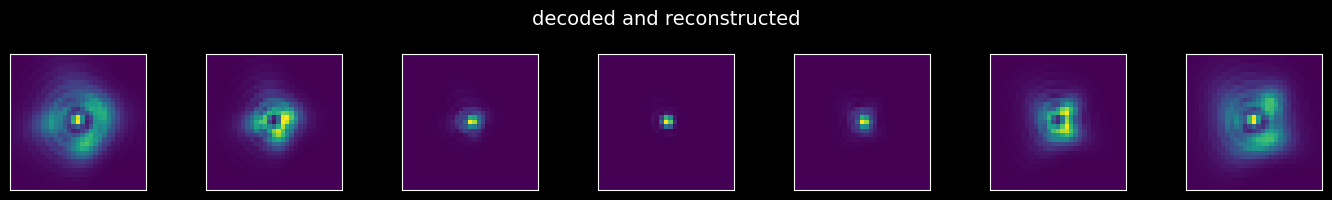

In [10]:
_ = generate_reconstruct_plot(solver, rng_seed+2)

Seed set to 126


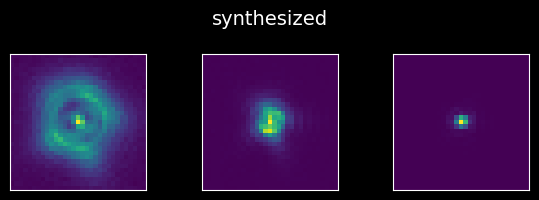

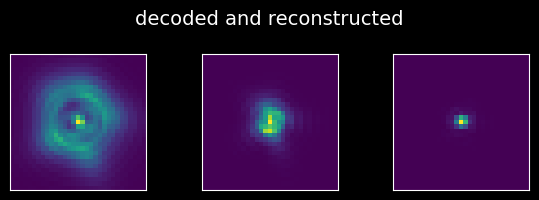

In [11]:
_ = generate_reconstruct_plot(solver, rng_seed+3)

Seed set to 127


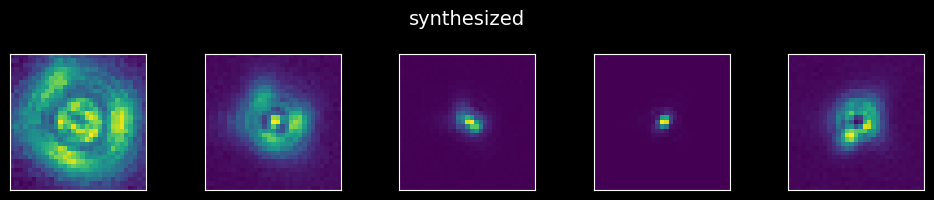

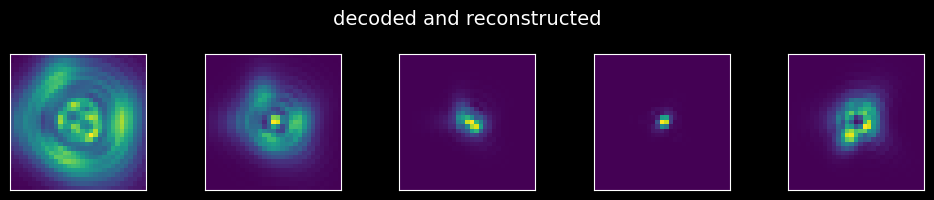

In [12]:
_ = generate_reconstruct_plot(solver, rng_seed+4)

Seed set to 128


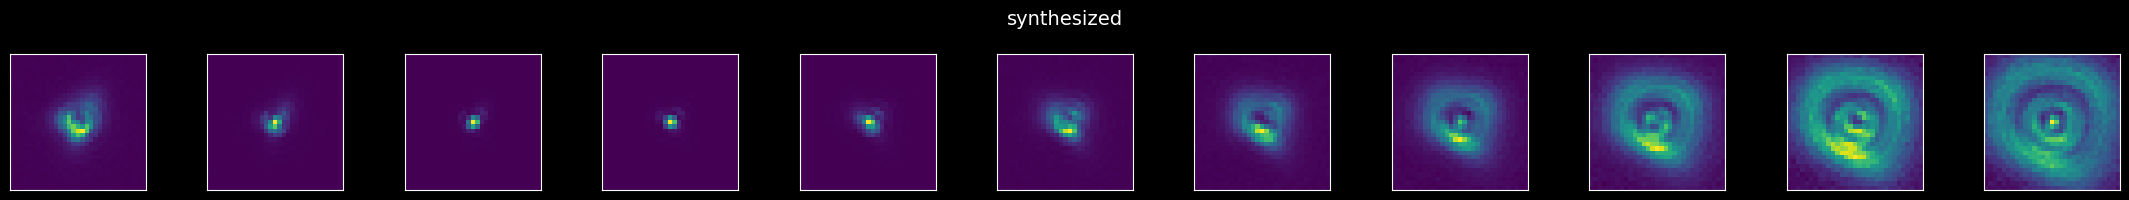

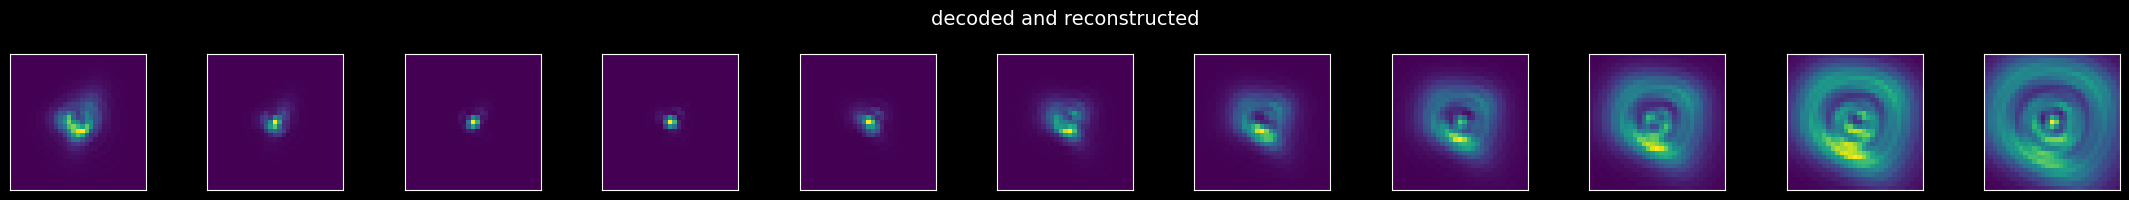

In [13]:
z, images, phase_coefs, amp_coefs, pred_images, pred_phase_coefs, pred_amp_coefs = generate_reconstruct_plot(solver, rng_seed+5)

Reusing that last example, randomly permute the z-positions, and make sure the results are identical apart from the same permutation:

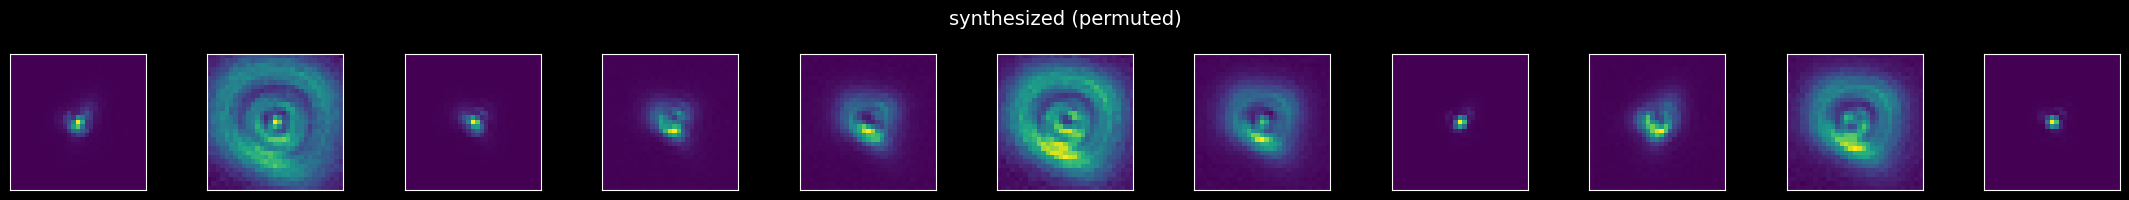

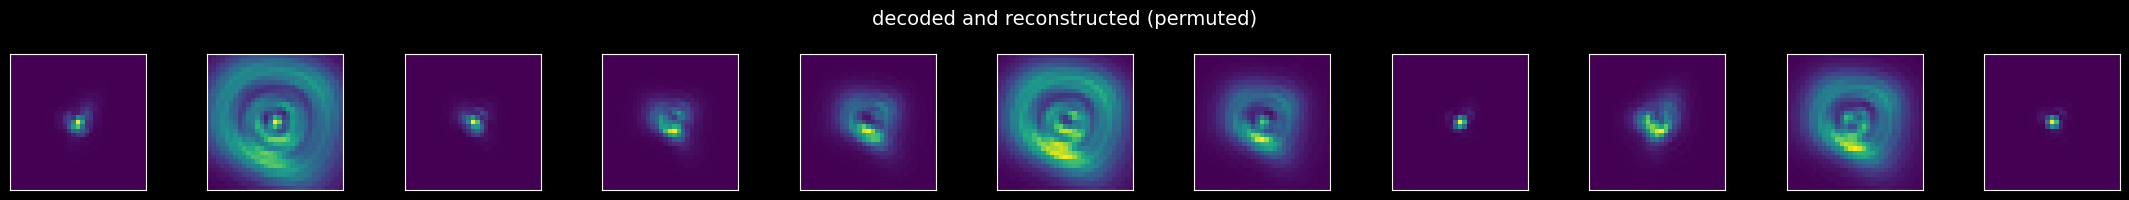

In [14]:
num_z = z.shape[-1]
perm_indices = torch.randperm(num_z)

perm_images = images[:, perm_indices, :, :]
perm_z = z[:, perm_indices]
with torch.inference_mode():
    perm_pred_phase_coefs, perm_pred_amp_coefs = solver.predict_coefficients(perm_images, perm_z)
    perm_pred_images = solver.simulator.simulate_normalized_stacks(
        perm_pred_phase_coefs, perm_pred_amp_coefs, perm_z
    )

fig1 = plot_stack(perm_images.squeeze(0).numpy(force=True), panel_size=2)
fig1.suptitle("synthesized (permuted)", size=14)
fig1.tight_layout()

fig2 = plot_stack(perm_pred_images.squeeze(0).numpy(force=True), panel_size=2)
fig2.suptitle("decoded and reconstructed (permuted)", size=14)
fig2.tight_layout()

In [15]:
print("Phase coefs are permutation-equivariant: ", torch.allclose(pred_phase_coefs, perm_pred_phase_coefs, rtol=1e-4))
print("Amp coefs are permutation-equivariant: ", torch.allclose(pred_amp_coefs, perm_pred_amp_coefs, rtol=1e-4))
print("Reconstructed images are permutation-equivariant: ", torch.allclose(pred_images[:, perm_indices, :, :], perm_pred_images, rtol=1e-4))

Phase coefs are permutation-equivariant:  False
Amp coefs are permutation-equivariant:  True
Reconstructed images are permutation-equivariant:  True


#### Attention weights and information content

Now let's have a bit of fun, and see how the z-pool attention weights compare to the total information. First, we generate a batch of labeled images and predictions that share a single geometry draw, so the results can be easily overlaid. This is a deconstruction of `StackSimulator.create_examples`, with a z-jitter of 0 injected to avoid a confounding factor. Each `ZstackSolver.forward` call (inside `predict_coefficients`, e.g.) logs the z-pool attention weights on the encoder, so grab those along with the sampled z-positions to plot.

In [16]:
_ = pl.seed_everything(rng_seed+6, workers=True)
batch_size = 64
sim = solver.simulator

z_list = []
attn_weight_list = []
with torch.inference_mode():
    phase_coefs, amp_coefs = sim.sample_coefficients(batch_size)
    z = sim.sample_geometry(batch_size)
    offsets = torch.zeros(batch_size, device=device)  # no z-jitter
    objects, _ = sim.object_distribution.sample_with_params(batch_size, None)
    images = sim.simulate_normalized_stacks(phase_coefs, amp_coefs, z, with_noise=True, offsets=offsets, objects=objects)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images, z)

    for bidx in range(batch_size):
        z_list.append(z[bidx].numpy(force=True))
        attn_weight_list.append(solver.head.trunk.last_pool_weights[bidx].numpy(force=True) * z.shape[-1])  # scale weights back up to 1

Seed set to 129


Next, calculate the total information vs. defocus the same way as in `example_3b` (yeah we're jumping around a bit in the ordering, apologies).

In [17]:
z_max = 2.0
num_z = 19
z_scan = torch.linspace(-z_max, z_max, num_z).to(device)

fisher_samples = []
coefs = sim.coefficients.gather_nonpinned(sim.coefficients.join(phase_coefs, amp_coefs))  # [B, C_kept]
for coefs_i in coefs:  # TODO - figure out a way to vectorize this later
    _, augmented_fisher = calculate_augmented_fisher_matrix(coefs_i, z_scan, sim)
    fisher_samples.append(augmented_fisher.numpy(force=True))

augmented_fisher_samples = np.stack(fisher_samples)  # [B, Z, C_kept+1, C_kept+1]
prior_covariance = augmented_prior_covariance(sim)  # [C_kept+1, C_kept+1]
information = calculate_mutual_information(augmented_fisher_samples, prior_covariance).mean(0)  # [Z,]

Plot the z-pool attention weights for each head, overlaid with the total information. Intuitively, we'd expect these to roughly line up, under the assumption that the model will have learned to pay the most attention to the most information-rich z-planes.

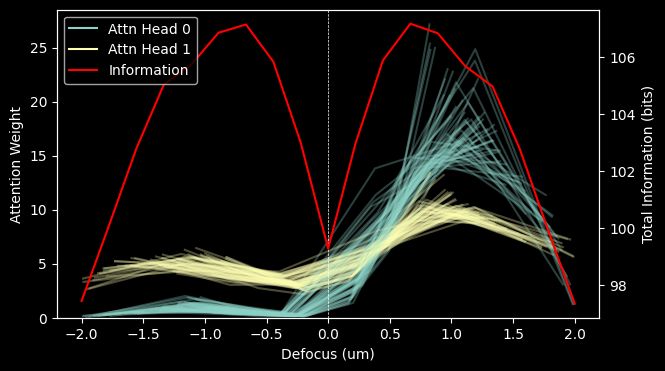

In [18]:
fig, ax = pyplot.subplots(figsize=(7, 4))
for i, (z_data, weight_data) in enumerate(zip(z_list, attn_weight_list)):
    for j in range(encoder_spec.num_attention_heads):
        ax.plot(z_data, len(z_data) * weight_data[j], alpha=0.3, color=f"C{j}")
ax.set_xlabel("Defocus (um)")
ax.set_ylabel("Attention Weight")
ax.set_ylim(bottom=0)
ax.axvline(0, ls="--", lw=0.5)

ax2 = ax.twinx()
ax2.plot(z_scan.numpy(force=True), information, color="r")
ax2.set_ylabel("Total Information (bits)")

legend_handles = [
    Line2D([0], [0], color=f"C{j}", label=f"Attn Head {j}")
    for j in range(encoder_spec.num_attention_heads)
]
legend_handles.append(Line2D([0], [0], color="r", label="Information"))
ax2.legend(handles=legend_handles, loc="upper left")

Reasonable agreement on the $z > 0$ side. Huzzah! The behavior on the $z < 0$ side is murkier: it's possible to convince oneself that the attention weights qualitatively match the information curve on that side, too, but the weight peaks are much smaller. This is probably a consequence of the focal plane degeneracy discussed in other examples, with the model arbitrarily (and without loss of accuracy) breaking the tie in favor of the $z > 0$ side in this case. It's entirely possible that retraining the model from a different seed would cause it to break the other way, but this is left as an exercise for the reader.

Finally, let's put the z-jitter back, since that's something that the model sees in the synthesized images and must learn to deal with.

In [19]:
_ = pl.seed_everything(rng_seed+7, workers=True)
batch_size = 64

z_list = []
attn_weight_list = []
with torch.inference_mode():
    phase_coefs, amp_coefs = sim.sample_coefficients(batch_size)
    z = sim.sample_geometry(batch_size)
    offsets = sim.sample_z_jitter(batch_size)  # sampled now, rather than zero
    objects, _ = sim.object_distribution.sample_with_params(batch_size, None)
    images = sim.simulate_normalized_stacks(phase_coefs, amp_coefs, z, with_noise=True, offsets=offsets, objects=objects)
    pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images, z)

    for bidx in range(batch_size):
        z_list.append(z[bidx].numpy(force=True))
        attn_weight_list.append(solver.head.trunk.last_pool_weights[bidx].numpy(force=True))

Seed set to 130


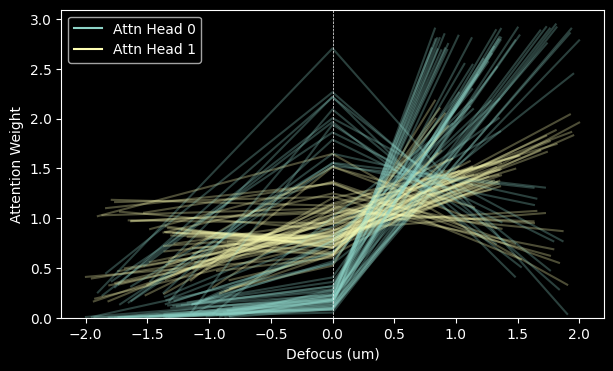

In [20]:
fig, ax = pyplot.subplots(figsize=(7, 4))
for i, (z_data, weight_data) in enumerate(zip(z_list, attn_weight_list)):
    for j in range(encoder_spec.num_attention_heads):
        ax.plot(z_data, len(z_data) * weight_data[j], alpha=0.3, color=f"C{j}")
ax.set_xlabel("Defocus (um)")
ax.set_ylabel("Attention Weight")
ax.set_ylim(bottom=0)
ax.axvline(0, ls="--", lw=0.5)

legend_handles = [
    Line2D([0], [0], color="C0", label="Attn Head 0"),
    Line2D([0], [0], color="C1", label="Attn Head 1"),
]
ax.legend(handles=legend_handles, loc="upper left")

The resulting plot is much messier, but this is a good thing. The z-stacks are rigidly offset by an amount sampled uniformly over [-1, +1] um (see way back at the top of the notebook). The fact that the attention weight peak that was previously at +1.0 um is now smeared over ~0.0-2.0 um is evidence that the model is learning and properly accounting for this jitter. Under these circumstances, we expect the plot to look like garbage, and it does not disappoint. Or maybe it does, the terminology gets weird here.